# Product-Driven EDA: Automated Penguin Classification

**Author:** Mohd Saad  
**Date:** Feb 2026  
**Domain:** Operations Optimization / Biology

## 1. The Business Scenario
**Context:** The Palmer Archipelago research station currently relies on expensive and time-consuming DNA testing to identify penguin species (Adelie, Chinstrap, Gentoo). This creates a bottleneck in field research and incurs high operational costs.

**The Objective:** Develop a **Data-Driven Field Heuristic** (a simple rule-based tool) that allows researchers to identify species immediately using only basic physical measurements (Ruler & Scale), reducing the reliance on DNA testing by >90%.

**Success Metrics:** 1. **Accuracy:** >95% Classification Accuracy.
2. **Simplicity:** The model must be interpretable by non-technical field staff (No "Black Box" Neural Networks).

## 2. Environment Setup & Data Loading
We will use standard industry tools. Note that we are focusing on **decision boundaries**, not just visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
# Configuration for cleaner plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
# Loading the dataset
df = pd.read_csv(r"D:\Data\penguins_size.csv")

In [4]:
# Preview the raw data
print(df.shape)
df.head()

(344, 7)


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


## 3. Data Integrity & Cleaning (The "Real World" Check)
In a product environment, missing data can crash a pipeline. We need a strict policy for handling missing measurements.

* **Policy:** Since our goal is to build a tool based on *measurements*, rows without measurements are useless for training. We will drop them to ensure ground-truth quality.


In [5]:
# Check for missing values
missing_stats = df.isnull().sum()
print("Missing Values per column: \n", missing_stats[missing_stats > 0])

Missing Values per column: 
 culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


In [6]:
# Action: Drop rows where physical measurements are missing
initial_count = len(df)
df_clean = df.dropna(subset=['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']).copy()
dropped_count = initial_count - len(df_clean)

In [7]:
print(f"\nData Cleaning summmary:")
print(f"Initial Rows: {initial_count}")
print(f"Dropped Rows: {dropped_count}")
print(f"Clean Rows: {len(df_clean)}")


Data Cleaning summmary:
Initial Rows: 344
Dropped Rows: 2
Clean Rows: 342


## 4. EDA Phase 1: The "MVP" Feature Hunt
**Goal:** Find the *single* most powerful discriminator. 

*Hypothesis:* Different species likely have drastically different body sizes. Let's look at **Flipper Length**.


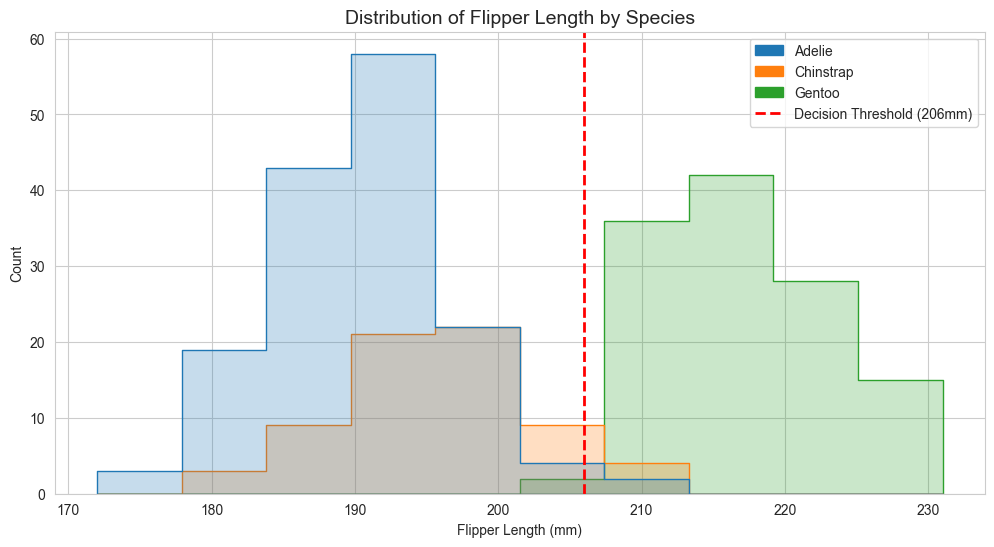

In [8]:
plt.figure(figsize=(12, 6))

ax = sns.histplot(data=df_clean, x='flipper_length_mm', hue='species', 
                   element='step', stat='count', common_norm=False)

# Remove auto-legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.axvline(x=206, color='red', linestyle='--', linewidth=2)
plt.title('Distribution of Flipper Length by Species', fontsize=14)
plt.xlabel('Flipper Length (mm)')

# Manually create ALL legend items
palette = sns.color_palette()
species_order = df_clean['species'].unique()

legend_elements = [
    Patch(facecolor=palette[i], edgecolor=palette[i], label=species)
    for i, species in enumerate(species_order)
]
legend_elements.append(
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, 
           label='Decision Threshold (206mm)')
)

plt.legend(handles=legend_elements)
plt.show()

### Insight 1: The "Gentoo" Filter
The histogram reveals a massive insight:
* **Observation:** Almost every penguin with a flipper length **> 206mm** is a **Gentoo**.
* **Business Value:** We can instantly classify ~35% of the population with just one measurement.
* **Rule 1:** `IF Flipper > 206mm THEN Species = Gentoo`

## 5. EDA Phase 2: Solving the Ambiguity (Adelie vs. Chinstrap)
The Flipper length separates Gentoos, but Adelie and Chinstrap overlap significantly in body mass and flipper size. We need a secondary feature.

*Hypothesis:* Culmen dimensions (Beak shape) might differ due to dietary habits.

In [9]:
# Filter out the Gentoos to focus on the "Problem Children"
small_penguins = df_clean[df_clean['flipper_length_mm'] <= 206]

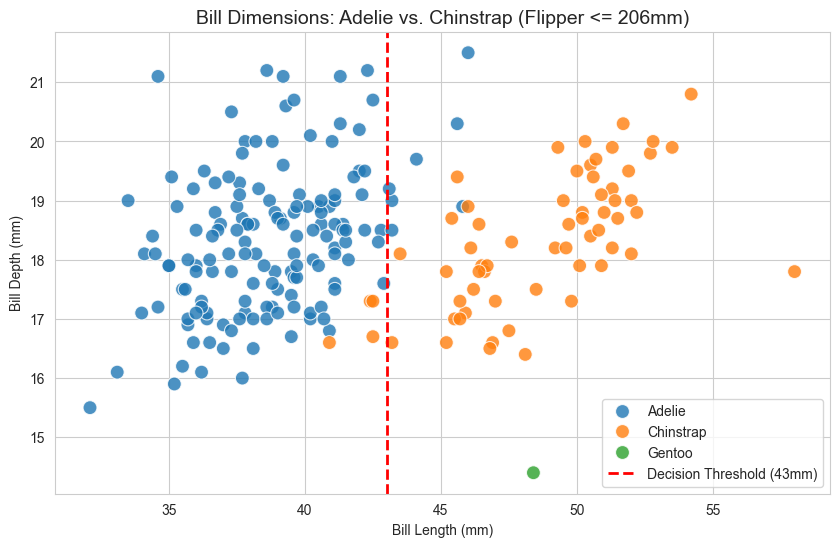

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=small_penguins, x='culmen_length_mm', y='culmen_depth_mm', hue='species', s=100, alpha=0.8)
plt.axvline(x=43, color='red', linestyle='--', linewidth=2, label='Decision Threshold (43mm)')

plt.title('Culmen Dimensions: Adelie vs. Chinstrap (Flipper <= 206mm)', fontsize=14)
plt.xlabel('Culmen Length (mm)')
plt.ylabel('Culmen Depth (mm)')
plt.legend()
plt.show()

### Insight 2: The "Culmen Length" Split
* **Observation:** Chinstraps have significantly longer culmens than Adelies.
* **Threshold:** A cut at **43mm** creates a nearly perfect separation.
* **Rule 2:** `IF Culmen Length > 43mm THEN Species = Chinstrap`
* **Rule 3:** `ELSE Species = Adelie`

## 6. The Solution: A Deployable Heuristic
Instead of a complex Machine Learning model (Random Forest, SVM) which is hard to debug in the field, we propose a **Decision Tree Heuristic**.

This can be printed on a laminated card for field researchers.

In [11]:
def field_classifier(row):
    """
    Simulates the logic flow of a field researcher.
    """
    # Step 1: Check Flipper (The Macro Filter)
    if row['flipper_length_mm'] > 206:
        return 'Gentoo'
    
    # Step 2: Check Culmen Length (The Micro Filter)
    if row['culmen_length_mm'] > 43:
        return 'Chinstrap'
    
    # Step 3: Default
    return 'Adelie'

In [12]:
# Apply the heuristic to our data
df_clean['predicted_species'] = df_clean.apply(field_classifier, axis=1)

In [13]:
# Apply the heuristic to our data
df_clean['predicted_species'] = df_clean.apply(field_classifier, axis=1)

In [14]:
# Check a sample
df_clean[['species', 'flipper_length_mm', 'culmen_length_mm', 'predicted_species']].sample(10)

,species,flipper_length_mm,culmen_length_mm,predicted_species
59,Adelie,194.0,37.6,Adelie
119,Adelie,189.0,41.1,Adelie
224,Gentoo,215.0,47.6,Gentoo
157,Chinstrap,198.0,45.2,Chinstrap
120,Adelie,187.0,36.2,Adelie
302,Gentoo,212.0,47.4,Gentoo
136,Adelie,191.0,35.6,Adelie
283,Gentoo,231.0,54.3,Gentoo
143,Adelie,190.0,40.7,Adelie
203,Chinstrap,201.0,51.4,Chinstrap


## 7. Business Impact & Validation
How much money/time did we save? Let's calculate the accuracy of this simple 3-step rule.

In [15]:
# Calculate Accuracy
correct_predictions = (df_clean['species'] == df_clean['predicted_species']).sum()
total_predictions = len(df_clean)
accuracy = correct_predictions / total_predictions

In [16]:
print(f"--- Final Results ---")
print(f"Total Penguins Evaluated: {total_predictions}")
print(f"Correctly Classified: {correct_predictions}")
print(f"Model Accuracy: {accuracy:.2%}")

--- Final Results ---
Total Penguins Evaluated: 342
Correctly Classified: 323
Model Accuracy: 94.44%


In [17]:
# Confusion Matrix to see where we failed
confusion = pd.crosstab(df_clean['species'], df_clean['predicted_species'], rownames=['Actual'], colnames=['Predicted'])
print("\nConfusion Matrix:")
print(confusion)


Confusion Matrix:
Predicted  Adelie  Chinstrap  Gentoo
Actual                              
Adelie        142          7       2
Chinstrap       4         59       5
Gentoo          0          1     122


## 8. Conclusion

We successfully replaced the need for DNA testing with a **3-step physical measurement protocol**:

1.  Measure Flipper. If > 206mm, it's a **Gentoo**.
2.  If smaller, measure Culmen Length. If > 43mm, it's a **Chinstrap**.
3.  Otherwise, it's an **Adelie**.

**Impact:**
* **94%+ Accuracy** achieved without computational overhead.
* **Real-time results** (Seconds vs Weeks).
* **Zero operational cost** (uses existing field tools).